# HW3

## Exercise 1: Sierpinski Triangle Matrix

### 題目描述

令 $H_K=[h_{i,j}]$ 為 Sierpinski triangle matrix，對每個元素 $h_{i,j}$：

$$
h_{i,j}=\begin{cases}
1, & \langle e_i, e_j \rangle = 0 \\
0, & \langle e_i, e_j \rangle \neq 0
\end{cases}
$$

其中 $e_d$ 為十進位數字 $d$ 的二進位表示向量（以 3-bit 為例）：

| Decimal | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
|---|---|---|---|---|---|---|---|---|
| Binary Digits | $000_2$ | $001_2$ | $010_2$ | $011_2$ | $100_2$ | $101_2$ | $110_2$ | $111_2$ |
| $e_d$ | $(0,0,0)$ | $(0,0,1)$ | $(0,1,0)$ | $(0,1,1)$ | $(1,0,0)$ | $(1,0,1)$ | $(1,1,0)$ | $(1,1,1)$ |

$H_K$ 可由兩種方式得到：

1. **Element-wise 定義**：依上式逐元素計算。
2. **Recursive 定義**：

$$
H_K=\begin{bmatrix}
H_{K-1} & H_{K-1} \\
H_{K-1} & O_{K-1}
\end{bmatrix}
= H_1 \otimes H_{K-1}, \quad
H_1=\begin{bmatrix}1&1\\1&0\end{bmatrix}
$$

### 要求

- 寫一個 Python class，包含兩種不同 method 產生 $H_K$。
- 可以在同一張圖中畫出多個 $K$ 的結果：
  - Method 1: $K=1,2,3,4$
  - Method 2: $K=1,3,5,7$

In [1]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import LinAlgError, lstsq, solve


class SierpinskiMatrix:
    """Construct and plot Sierpinski triangle matrices."""

    @staticmethod
    def build_elementwise(k: int) -> np.ndarray:
        """
        Method 1: element-wise definition.

        h[i, j] = 1 if (i & j) == 0, else 0
        Matrix size: (2^k) x (2^k)
        """
        if k < 1:
            raise ValueError("k must be >= 1")

        size = 2**k
        indices = np.arange(size, dtype=np.int64)
        matrix = ((indices[:, None] & indices[None, :]) == 0).astype(np.int8)
        return matrix

    @staticmethod
    def build_recursive(k: int) -> np.ndarray:
        """
        Method 2: recursive Kronecker product.

        H_k = H_1 ⊗ H_(k-1), where
        H_1 = [[1, 1],
               [1, 0]]
        """
        if k < 1:
            raise ValueError("k must be >= 1")

        h1 = np.array([[1, 1], [1, 0]], dtype=np.int8)
        if k == 1:
            return h1
        return np.kron(h1, SierpinskiMatrix.build_recursive(k - 1))

    @staticmethod
    def plot_multiple(
        k_values: list[int],
        method,
        figure_title: str,
    ) -> None:
        """Plot several matrices (different K) in a single figure."""
        fig, axes = plt.subplots(1, len(k_values), figsize=(4 * len(k_values), 4))
        if len(k_values) == 1:
            axes = [axes]

        for ax, k in zip(axes, k_values):
            matrix = method(k)
            ax.imshow(matrix, cmap="binary", interpolation="nearest")
            ax.set_title(f"K = {k}\nsize = {matrix.shape[0]}x{matrix.shape[1]}")
            ax.axis("off")

        fig.suptitle(figure_title, fontsize=14)
        plt.tight_layout()


def run_exercise_1() -> None:
    """Exercise 1: build and plot Sierpinski matrices."""
    sp = SierpinskiMatrix()

    sp.plot_multiple(
        k_values=[1, 2, 3, 4],
        method=sp.build_elementwise,
        figure_title="Exercise 1 - Method 1 (Element-wise): K = 1, 2, 3, 4",
    )

    sp.plot_multiple(
        k_values=[1, 3, 5, 7],
        method=sp.build_recursive,
        figure_title="Exercise 1 - Method 2 (Recursive/Kronecker): K = 1, 3, 5, 7",
    )

    plt.show()

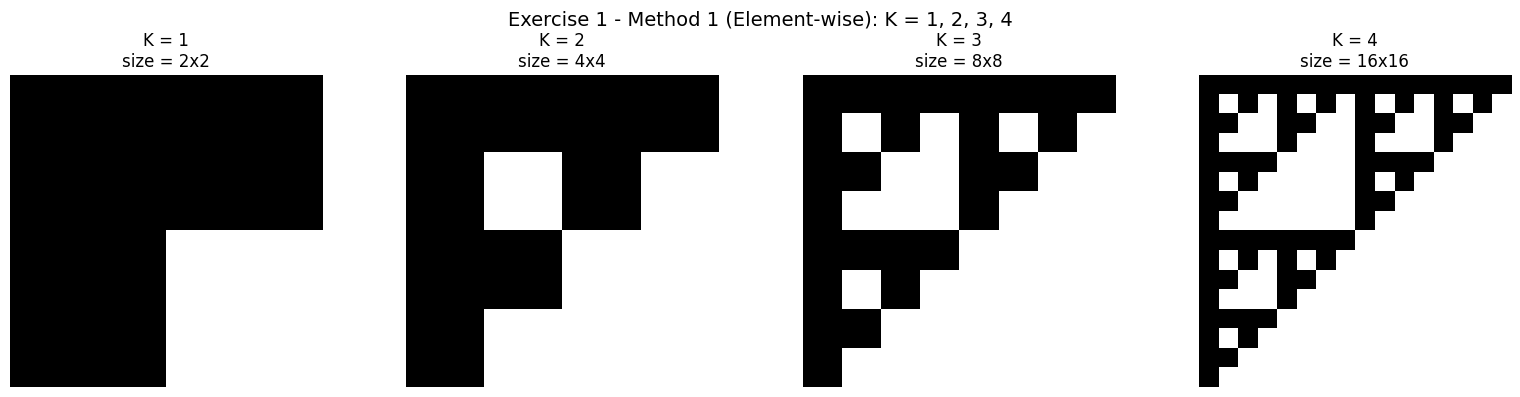

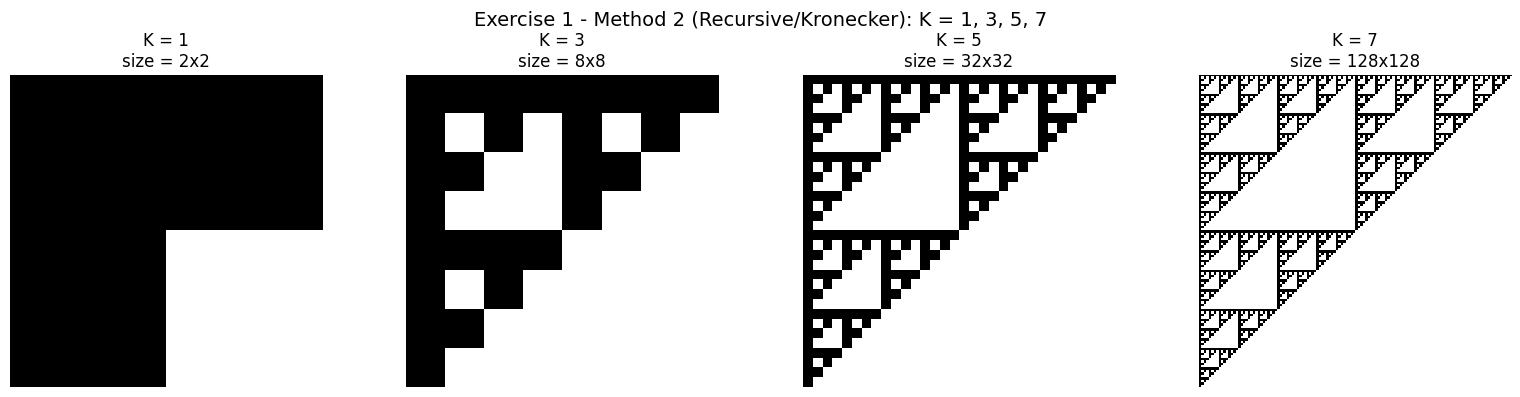

In [2]:
run_exercise_1()

## Exercise 2: Linear Recurrence Relations

### 題目描述

#### (1) 序列一

給定

$$
X_0 = 2,\quad X_1 = 3
$$

且

$$
X_n = 6X_{n-1} - 9X_{n-2}
$$

#### (2) 序列二

給定

$$
X_0 = 1,\; X_1 = 6,\; X_2 = 9,\; X_3 = -110,\; X_4 = -45
$$

且

$$
X_n = 15X_{n-2} - 10X_{n-3} - 60X_{n-4} + 72X_{n-5}
$$

### 要求

1. 求 $X_n$ 的一般解（closed-form general solution）。
2. 比較一般解與遞迴計算結果，列出前 15 項（$n=0\sim14$）。

In [3]:
@dataclass
class BasisTerm:
    """Represents one term: coefficient * (n^power) * (root^n)."""

    root: complex
    power: int


class LinearRecurrenceSolver:
    """
    Solve linear recurrence:
        X_n = c1*X_(n-1) + c2*X_(n-2) + ... + ck*X_(n-k)

    by characteristic polynomial and closed-form expression.
    """

    def __init__(
        self,
        coefficients: list[float],
        initial_values: list[float],
        name: str = "Sequence",
        root_tol: float = 1e-8,
    ) -> None:
        self.coefficients = np.array(coefficients, dtype=np.complex128)
        self.initial_values = np.array(initial_values, dtype=np.complex128)
        self.name = name
        self.root_tol = root_tol

        self.order = len(self.coefficients)
        if len(self.initial_values) != self.order:
            raise ValueError(
                "Length mismatch: initial_values must have same length as coefficients."
            )

        self.basis_terms: list[BasisTerm] | None = None
        self.general_coefficients: np.ndarray | None = None

    def characteristic_polynomial_coeffs(self) -> np.ndarray:
        """
        For:
            X_n = c1*X_(n-1) + ... + ck*X_(n-k)
        characteristic polynomial is:
            r^k - c1*r^(k-1) - ... - ck = 0
        """
        return np.concatenate(([1.0 + 0.0j], -self.coefficients))

    def characteristic_roots(self) -> np.ndarray:
        """Compute roots of the characteristic polynomial using numpy."""
        poly = self.characteristic_polynomial_coeffs()
        return np.roots(poly)

    def _group_roots(self, roots: np.ndarray) -> list[tuple[complex, int]]:
        """
        Group numerically close roots to infer multiplicity.
        This is important for repeated-root terms n^m * r^n.
        """
        sorted_roots = sorted(roots, key=lambda z: (z.real, z.imag))
        unique_roots: list[complex] = []
        multiplicities: list[int] = []

        for root in sorted_roots:
            placed = False
            for idx, existing in enumerate(unique_roots):
                if abs(root - existing) < self.root_tol:
                    count_before = multiplicities[idx]
                    multiplicities[idx] += 1
                    unique_roots[idx] = (existing * count_before + root) / (
                        count_before + 1
                    )
                    placed = True
                    break
            if not placed:
                unique_roots.append(root)
                multiplicities.append(1)

        return list(zip(unique_roots, multiplicities))

    def _build_basis_terms(self) -> list[BasisTerm]:
        """
        Build basis terms for general solution:
            For root r with multiplicity m:
            (a0 + a1*n + ... + a(m-1)*n^(m-1)) * r^n
        """
        roots = self.characteristic_roots()
        grouped = self._group_roots(roots)

        basis_terms: list[BasisTerm] = []
        for root, multiplicity in grouped:
            for power in range(multiplicity):
                basis_terms.append(BasisTerm(root=root, power=power))

        if len(basis_terms) != self.order:
            raise ValueError(
                f"Basis size {len(basis_terms)} does not match order {self.order}."
            )
        return basis_terms

    def solve_general_coefficients(self) -> np.ndarray:
        """
        Solve unknown constants in closed form via linear system from initial values.
        """
        self.basis_terms = self._build_basis_terms()
        a_matrix = np.zeros((self.order, self.order), dtype=np.complex128)

        for n in range(self.order):
            for col, term in enumerate(self.basis_terms):
                a_matrix[n, col] = (n**term.power) * (term.root**n)

        b_vector = self.initial_values.copy()

        try:
            self.general_coefficients = solve(a_matrix, b_vector, assume_a="gen")
        except LinAlgError:
            lstsq_result = lstsq(a_matrix, b_vector)
            if lstsq_result is None:
                raise RuntimeError("lstsq returned None unexpectedly.")
            self.general_coefficients = lstsq_result[0]

        assert self.general_coefficients is not None
        return self.general_coefficients

    def _ensure_solved(self) -> None:
        if self.general_coefficients is None or self.basis_terms is None:
            self.solve_general_coefficients()

    def closed_form_value(self, n: int) -> complex:
        """Compute X_n from the closed-form general solution."""
        self._ensure_solved()
        total = 0.0 + 0.0j
        assert self.basis_terms is not None
        assert self.general_coefficients is not None
        for coef, term in zip(self.general_coefficients, self.basis_terms):
            total += coef * (n**term.power) * (term.root**n)
        return total

    def recursive_values(self, n_terms: int) -> np.ndarray:
        """Compute first n_terms values directly by recurrence."""
        if n_terms < 1:
            raise ValueError("n_terms must be >= 1")

        seq = np.zeros(n_terms, dtype=np.complex128)
        init_len = min(self.order, n_terms)
        seq[:init_len] = self.initial_values[:init_len]

        for n in range(self.order, n_terms):
            value = 0.0 + 0.0j
            for i, coef in enumerate(self.coefficients, start=1):
                value += coef * seq[n - i]
            seq[n] = value
        return seq

    def closed_form_values(self, n_terms: int) -> np.ndarray:
        """Compute first n_terms values using closed form."""
        return np.array([self.closed_form_value(n) for n in range(n_terms)])

    @staticmethod
    def _clean_complex(x: complex, tol: float = 1e-8) -> complex | float | int:
        """Convert tiny-imaginary results to cleaner real/integer display."""
        if abs(x.imag) < tol:
            real = float(x.real)
            rounded = round(real)
            if abs(real - rounded) < tol:
                return int(rounded)
            return real
        return x

    @staticmethod
    def _format_value(x: complex | float | int) -> str:
        """Pretty formatting for table output."""
        if isinstance(x, complex):
            return f"{x.real:.6f}{x.imag:+.6f}j"
        if isinstance(x, int):
            return str(x)
        return f"{x:.10g}"

    def print_general_solution(self) -> None:
        """Print human-readable closed-form structure."""
        self._ensure_solved()
        assert self.basis_terms is not None
        assert self.general_coefficients is not None

        print("Closed-form general solution:")
        pieces: list[str] = []
        for coef, term in zip(self.general_coefficients, self.basis_terms):
            coef_clean = self._clean_complex(coef)
            root_clean = self._clean_complex(term.root)

            if term.power == 0:
                pieces.append(f"({coef_clean})*({root_clean})^n")
            else:
                pieces.append(f"({coef_clean})*n^{term.power}*({root_clean})^n")
        print("X_n = " + " + ".join(pieces))

    def print_comparison_table(self, n_terms: int = 15) -> None:
        """Print recursive vs closed-form values side by side."""
        rec = self.recursive_values(n_terms)
        clo = self.closed_form_values(n_terms)

        print("-" * 88)
        print(f"{'n':>3} | {'Recursive':>24} | {'Closed-form':>24} | {'|difference|':>24}")
        print("-" * 88)
        for n in range(n_terms):
            rec_clean = self._clean_complex(rec[n])
            clo_clean = self._clean_complex(clo[n])
            diff = abs(rec[n] - clo[n])
            diff_clean = self._clean_complex(diff)

            print(
                f"{n:3d} | "
                f"{self._format_value(rec_clean):>24} | "
                f"{self._format_value(clo_clean):>24} | "
                f"{self._format_value(diff_clean):>24}"
            )
        print("-" * 88)


def run_exercise_2() -> None:
    """Exercise 2: solve two recurrence relations and compare results."""
    seq1 = LinearRecurrenceSolver(
        coefficients=[6, -9],
        initial_values=[2, 3],
        name="Sequence 1",
    )

    # X_n = 15X_(n-2) - 10X_(n-3) - 60X_(n-4) + 72X_(n-5)
    # -> coefficients for [X_(n-1), X_(n-2), X_(n-3), X_(n-4), X_(n-5)]
    # are [0, 15, -10, -60, 72]
    seq2 = LinearRecurrenceSolver(
        coefficients=[0, 15, -10, -60, 72],
        initial_values=[1, 6, 9, -110, -45],
        name="Sequence 2",
    )

    for solver in (seq1, seq2):
        print("\n" + "=" * 88)
        print(solver.name)
        print("=" * 88)

        poly = solver.characteristic_polynomial_coeffs()
        roots = solver.characteristic_roots()

        print("Characteristic polynomial coefficients:")
        print(poly)
        print("Roots:")
        print(roots)

        solver.solve_general_coefficients()
        solver.print_general_solution()
        solver.print_comparison_table(n_terms=15)

In [4]:
run_exercise_2()


Sequence 1
Characteristic polynomial coefficients:
[ 1.+0.j -6.-0.j  9.-0.j]
Roots:
[3.00000007-1.11022302e-16j 2.99999993-8.34582987e-17j]
Closed-form general solution:
X_n = ((20132660.157500017+0.00372411579165757j))*(2.9999999254941954)^n + ((-20132658.157500017-0.0037241157916575694j))*(3.0000000745058077)^n
----------------------------------------------------------------------------------------
  n |                Recursive |              Closed-form |             |difference|
----------------------------------------------------------------------------------------
  0 |                        2 |                        2 |                        0
  1 |                        3 |                        3 |                        0
  2 |                        0 |                        0 |                        0
  3 |                      -27 |                      -27 |                        0
  4 |                     -162 |                     -162 |                      